# Notebook 18 — All five windows, for every research question (viva item 8)

**Examiner's comment (31 Jul 2026, item 8):**
> *Temporal Analysis: the analysis must cover all windows (1, 7, 14, 21, and 28 days) before
> reaching a final conclusion.*

"Window" is read two ways in this project, so this notebook covers both rather than guessing.

### Part A — forecast horizon (the reading that exposes a real gap)
H1, H2 and H5 already report all five horizons. **H3 (attention / domain validation) and H4
(computational efficiency) did not** — both were measured at a single setting and then generalised.
Part A repeats each of them at h = 1, 7, 14, 21, 28 over the same 30 seeds, so the H3 and H4
conclusions are drawn only after all five horizons have been seen.

### Part B — input window length (SEQ_LEN)
The thesis fixes the LSTM input window at 28 days on the epidemiological argument that it spans one
full Aedes breeding-to-bite-to-illness cycle. That is a design justification, not evidence. Part B
sweeps SEQ_LEN over 1, 7, 14, 21 and 28 days and tests whether 28 is actually the better choice, so
the claim is defended empirically.

> **Note on SEQ_LEN = 1.** With a single time step the LSTM has no sequence to summarise and the
> temporal attention degenerates to a weight of 1.0 on one step. It is included because the examiner
> named it, and it doubles as the strongest possible evidence that the recurrent path is doing work.

**Runtime.** Part A ≈ 1 h, Part B ≈ 2 h on a GPU machine.

In [1]:
import os, sys, time, json, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, os.getcwd())
import tensorflow as tf
from sklearn.preprocessing import RobustScaler

from viva_revision_common import (
    SEEDS, N_SEEDS, HORIZONS, SEQ_LEN, ALPHA,
    build_features, feature_sets, build_lstm_transformer, build_standalone_lstm,
    score, fit_target_scaler, train_model, predict, release,
    paired_test, holm, decide, ci_mean, summarise, boxplot_mean_median, LEGEND_NOTE,
)

os.makedirs('metrics', exist_ok=True); os.makedirs('plots', exist_ok=True)
plt.rcParams.update({'font.size': 9, 'figure.dpi': 130})
print('TF devices:', tf.config.list_physical_devices())

viva_revision_common loaded — 30 seeds 42..245, horizons [1, 7, 14, 21, 28]
TF devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [2]:
BENCH_CSV = 'singapore_dengue_weather_2013_2022.csv'
df = build_features(pd.read_csv(BENCH_CSV))
rf_features, dl_seq_features, dl_feat_features = feature_sets(df)

TRAIN_FRAC = 0.8
n_tr = int(len(df) * TRAIN_FRAC)
seq_scaler  = RobustScaler().fit(df[dl_seq_features].values[:n_tr])
feat_scaler = RobustScaler().fit(df[dl_feat_features].values[:n_tr])
X_seq  = seq_scaler.transform(df[dl_seq_features].values)
X_feat = feat_scaler.transform(df[dl_feat_features].values)
y_raw  = df['dengue_cases'].values


def split_for(h, seq_len=SEQ_LEN):
    '''Chronological 80/20 split, sequences built separately within each part so
    that no test window contains a training day.'''
    def seqs(a, b):
        Xs, Xf, Y = [], [], []
        for i in range(a + seq_len, b - h):
            Xs.append(X_seq[i - seq_len:i]); Xf.append(X_feat[i]); Y.append(y_raw[i + h])
        return np.array(Xs), np.array(Xf), np.array(Y)
    return seqs(0, n_tr), seqs(n_tr, len(df))


print(f'{len(df):,} records · {len(dl_seq_features)} sequence features · '
      f'{len(dl_feat_features)} branch features · train/test = {n_tr}/{len(df)-n_tr}')

3,611 records · 60 sequence features · 44 branch features · train/test = 2888/723


## Part A.1 — H3 (attention → domain validation) at every horizon

The domain categorisation is the rule used in Notebook 09, reproduced exactly: a feature counts as
domain-validated if it belongs to Case History, Temperature, Rainfall, Humidity or Wind Speed —
the five families the dengue literature establishes as drivers. Calendar/other features do not count.

For every horizon:

* `H0: π ≤ 0.70` — at most 70% of the top-20 attention-ranked features are domain-validated
* `Ha: π > 0.70`
* exact one-sided binomial test; Holm-corrected across the five horizons

In [3]:
CASE_PFX = ['cases_lag_', 'cases_mean_', 'cases_std_', 'cases_max_', 'cases_ema_', 'cases_diff_']
DOMAIN_VALIDATED = {'Case History', 'Temperature', 'Rainfall', 'Humidity', 'Wind Speed'}


def categorize(name):
    if name == 'cases_7d_avg' or any(name.startswith(p) for p in CASE_PFX):
        return 'Case History'
    if name.startswith('temp'):     return 'Temperature'
    if name.startswith('rain'):     return 'Rainfall'
    if name.startswith('humid'):    return 'Humidity'
    if name.startswith('wind'):     return 'Wind Speed'
    return 'Calendar/Other'


CATS = np.array([categorize(f) for f in dl_seq_features])
IS_DOMAIN = np.array([c in DOMAIN_VALIDATED for c in CATS])


def importance_and_profile(model, Xs_te, Xf_te):
    '''Attention-weighted feature importance, identical to Notebook 09 cell 11:
    importance_f = mean over samples of  sum_t ( alpha_t * |x_{t,f}| ).

    The attention weights are read by rebuilding the encoder up to the
    LayerNormalization output and calling the TemporalAttention layer directly,
    which populates its `attention_weights` attribute.'''
    ln = [l for l in model.layers if isinstance(l, tf.keras.layers.LayerNormalization)][0]
    encoder = tf.keras.Model(model.inputs, ln.output)
    hid = encoder.predict([Xs_te, Xf_te], verbose=0)
    attn_layer = [l for l in model.layers if 'temp_attn' in l.name][0]
    _ = attn_layer(tf.convert_to_tensor(hid, dtype=tf.float32))
    a = attn_layer.attention_weights.numpy().squeeze(-1)             # (n_samples, T)
    imp = (np.abs(Xs_te) * a[:, :, None]).sum(axis=1).mean(axis=0)   # (n_features,)
    return imp, a.mean(axis=0)


t0 = time.time()
h3_rows, h3_profiles, h3_importances = [], {}, {}

for h in HORIZONS:
    (Xs_tr, Xf_tr, y_tr), (Xs_te, Xf_te, y_te) = split_for(h)
    tgt = fit_target_scaler(y_tr, clip_pct=None)
    y_tr_sc = tgt.transform(y_tr.reshape(-1, 1)).ravel()

    imps, profs = [], []
    print(f'\n=== H3 at h = {h} d ===')
    for si, seed in enumerate(SEEDS):
        m = train_model(seed, build_lstm_transformer, Xs_tr, Xf_tr, y_tr_sc)
        p = predict(m, Xs_te, Xf_te, tgt)
        s = score(y_te, p)
        imp, prof = importance_and_profile(m, Xs_te, Xf_te)
        imps.append(imp); profs.append(prof)

        order = np.argsort(imp)[::-1]
        top20, top10 = order[:20], order[:10]
        h3_rows.append(dict(horizon=h, seed=seed, rmse=s['rmse'], r2=s['r2'],
                            hits20=int(IS_DOMAIN[top20].sum()), hits10=int(IS_DOMAIN[top10].sum()),
                            top1=dl_seq_features[order[0]]))
        release(m)
        if (si + 1) % 10 == 0:
            print(f'   seed {si+1}/{N_SEEDS}  ({(time.time()-t0)/60:.1f} min)')

    h3_importances[h] = np.array(imps)
    h3_profiles[h] = np.array(profs)

H3 = pd.DataFrame(h3_rows)
H3.to_csv('metrics/nb18_h3_per_horizon_per_seed.csv', index=False)
with open('metrics/nb18_h3_attention_by_horizon.pkl', 'wb') as f:
    pickle.dump({'importance': h3_importances, 'profile': h3_profiles,
                 'features': dl_seq_features, 'is_domain': IS_DOMAIN}, f)
print(f'\nPart A.1 done in {(time.time()-t0)/60:.1f} min')


=== H3 at h = 1 d ===

   seed 10/30  (2.7 min)
   seed 20/30  (5.8 min)
   seed 30/30  (8.7 min)

=== H3 at h = 7 d ===
   seed 10/30  (11.8 min)
   seed 20/30  (15.2 min)
   seed 30/30  (18.7 min)

=== H3 at h = 14 d ===
   seed 10/30  (22.4 min)
   seed 20/30  (25.6 min)
   seed 30/30  (29.2 min)

=== H3 at h = 21 d ===
   seed 10/30  (32.8 min)
   seed 20/30  (42.7 min)
   seed 30/30  (51.9 min)

=== H3 at h = 28 d ===
   seed 10/30  (56.9 min)
   seed 20/30  (63.8 min)
   seed 30/30  (70.1 min)

Part A.1 done in 70.1 min


In [4]:
rows = []
for h in HORIZONS:
    sub = H3[H3.horizon == h]
    cons = h3_importances[h].mean(axis=0)                  # consensus ranking across seeds
    order = np.argsort(cons)[::-1]
    k20, k10 = int(IS_DOMAIN[order[:20]].sum()), int(IS_DOMAIN[order[:10]].sum())
    bt = stats.binomtest(k20, 20, 0.70, alternative='greater')
    ci = bt.proportion_ci(confidence_level=0.95, method='exact')
    rows.append(dict(
        horizon=f'h={h}d',
        consensus_hits20=f'{k20}/20', consensus_rate=k20 / 20,
        ci_lo=ci.low, ci_hi=ci.high, p_binomial=bt.pvalue,
        consensus_hits10=f'{k10}/10',
        per_seed_hits20_mean=sub.hits20.mean(), per_seed_hits20_median=sub.hits20.median(),
        seeds_meeting_criterion=f'{int((sub.hits20 >= 14).sum())}/{len(sub)}',
        rmse_mean=sub.rmse.mean(), rmse_median=sub.rmse.median(), rmse_sd=sub.rmse.std(ddof=1),
        r2_mean=sub.r2.mean(),
        top_feature=dl_seq_features[order[0]]))

H3T = pd.DataFrame(rows)
H3T['p_holm'] = holm(H3T['p_binomial'])
H3T['decision'] = [decide(p) for p in H3T['p_holm']]
H3T.to_csv('metrics/nb18_h3_horizon_tests.csv', index=False)
pd.set_option('display.width', 220, 'display.max_columns', 40)
print('H3 — H0: pi <= 0.70 (top-20 domain-validated share)   Ha: pi > 0.70\n')
print(H3T.round(4).to_string(index=False))
print(f'\nH3 conclusion across ALL five horizons: '
      f'{"supported at every horizon" if (H3T.decision == "Reject H0").all() else "NOT supported at every horizon — see table"}')

H3 — H0: pi <= 0.70 (top-20 domain-validated share)   Ha: pi > 0.70

horizon consensus_hits20  consensus_rate  ci_lo  ci_hi  p_binomial consensus_hits10  per_seed_hits20_mean  per_seed_hits20_median seeds_meeting_criterion  rmse_mean  rmse_median  rmse_sd  r2_mean   top_feature  p_holm  decision
   h=1d            20/20             1.0 0.8609    1.0      0.0008            10/10                  20.0                    20.0                   30/30    30.3508      30.2185   1.8725   0.7112   cases_std_7   0.004 Reject H0
   h=7d            20/20             1.0 0.8609    1.0      0.0008            10/10                  20.0                    20.0                   30/30    31.5511      31.1339   1.9103   0.6897   cases_std_7   0.004 Reject H0
  h=14d            20/20             1.0 0.8609    1.0      0.0008            10/10                  20.0                    20.0                   30/30    32.8642      32.4668   1.7375   0.6660 cases_diff_14   0.004 Reject H0
  h=21d            

## Part A.2 — H4 (computational cost) at every horizon

`H0: cost ratio (ILT ÷ Standalone LSTM) ≥ 2` versus `Ha: ratio < 2`, tested separately at every
horizon on training time and inference latency. Parameter count and model size do not depend on the
horizon, so they are reported once as exact deterministic values.

In [5]:
t0 = time.time()
eff_rows = []
for h in HORIZONS:
    (Xs_tr, Xf_tr, y_tr), (Xs_te, Xf_te, y_te) = split_for(h)
    tgt = fit_target_scaler(y_tr, clip_pct=None)
    y_tr_sc = tgt.transform(y_tr.reshape(-1, 1)).ravel()
    print(f'\n=== H4 at h = {h} d ===')
    for name, builder in [('Standalone LSTM', build_standalone_lstm), ('ILT (proposed)', build_lstm_transformer)]:
        for si, seed in enumerate(SEEDS):
            t1 = time.time()
            m = train_model(seed, builder, Xs_tr, Xf_tr, y_tr_sc)
            train_s = time.time() - t1
            _ = m.predict([Xs_te[:32], Xf_te[:32]], verbose=0)      # warm up
            t2 = time.time()
            p = m.predict([Xs_te, Xf_te], verbose=0).ravel()
            infer_ms = (time.time() - t2) * 1000 / len(Xs_te)
            s = score(y_te, np.maximum(tgt.inverse_transform(p.reshape(-1, 1)).ravel(), 0))
            eff_rows.append(dict(horizon=h, model=name, seed=seed, train_s=train_s,
                                 latency_ms=infer_ms, params=int(m.count_params()),
                                 size_kb=m.count_params() * 4 / 1024,
                                 rmse=s['rmse'], r2=s['r2']))
            release(m)
        sub = [r for r in eff_rows if r['horizon'] == h and r['model'] == name]
        print(f'   {name:<16} train {np.mean([r["train_s"] for r in sub]):6.2f}s  '
              f'latency {np.mean([r["latency_ms"] for r in sub]):.4f} ms/sample  '
              f'({(time.time()-t0)/60:.1f} min)')

EFF = pd.DataFrame(eff_rows)
EFF.to_csv('metrics/nb18_h4_efficiency_per_horizon_per_seed.csv', index=False)
print(f'\nPart A.2 done in {(time.time()-t0)/60:.1f} min')


=== H4 at h = 1 d ===
   Standalone LSTM  train  27.62s  latency 0.4274 ms/sample  (16.3 min)
   ILT (proposed)   train  19.80s  latency 0.3647 ms/sample  (28.7 min)

=== H4 at h = 7 d ===
   Standalone LSTM  train  15.01s  latency 0.2850 ms/sample  (38.8 min)
   ILT (proposed)   train  18.56s  latency 0.3540 ms/sample  (51.0 min)

=== H4 at h = 14 d ===
   Standalone LSTM  train  13.89s  latency 0.2828 ms/sample  (61.1 min)
   ILT (proposed)   train  17.32s  latency 0.3602 ms/sample  (73.3 min)

=== H4 at h = 21 d ===
   Standalone LSTM  train  15.93s  latency 0.2924 ms/sample  (85.0 min)
   ILT (proposed)   train  20.78s  latency 0.3888 ms/sample  (99.7 min)

=== H4 at h = 28 d ===
   Standalone LSTM  train  15.23s  latency 0.2872 ms/sample  (111.6 min)
   ILT (proposed)   train  17.12s  latency 0.3460 ms/sample  (124.7 min)

Part A.2 done in 124.7 min


In [6]:
rows = []
for h in HORIZONS:
    L = EFF[(EFF.horizon == h) & (EFF.model == 'Standalone LSTM')].sort_values('seed')
    I = EFF[(EFF.horizon == h) & (EFF.model == 'ILT (proposed)')].sort_values('seed')
    for metric, col in [('Training time (s)', 'train_s'), ('Inference latency (ms/sample)', 'latency_ms')]:
        ratio = I[col].values / L[col].values             # paired by seed — tighter than mean/mean
        t, p2 = stats.ttest_1samp(ratio, 2.0)
        p1 = p2 / 2 if t < 0 else 1 - p2 / 2
        lo, hi = ci_mean(ratio)
        rows.append(dict(horizon=f'h={h}d', metric=metric,
                         lstm_mean=L[col].mean(), ilt_mean=I[col].mean(),
                         ratio_mean=ratio.mean(), ratio_median=np.median(ratio),
                         ratio_ci_lo=lo, ratio_ci_hi=hi, t_stat=t, p_value=p1))
    rows.append(dict(horizon=f'h={h}d', metric='Trainable parameters',
                     lstm_mean=L.params.mean(), ilt_mean=I.params.mean(),
                     ratio_mean=I.params.mean() / L.params.mean(),
                     ratio_median=I.params.mean() / L.params.mean(),
                     ratio_ci_lo=np.nan, ratio_ci_hi=np.nan, t_stat=np.nan, p_value=np.nan))

H4T = pd.DataFrame(rows)
m = H4T.p_value.notna()
H4T.loc[m, 'p_holm'] = holm(H4T.loc[m, 'p_value'])
H4T['decision'] = [decide(p) if pd.notna(p) else
                   ('Reject H0 (deterministic, ratio < 2)' if r < 2 else 'Fail to reject H0 (deterministic)')
                   for p, r in zip(H4T.p_holm, H4T.ratio_mean)]
H4T.to_csv('metrics/nb18_h4_horizon_tests.csv', index=False)
print('H4 — H0: cost ratio >= 2   Ha: cost ratio < 2   (paired per seed)\n')
print(H4T.round(4).to_string(index=False))
worst = H4T[H4T.metric != 'Trainable parameters']
print(f'\nH4 across ALL five horizons: '
      f'{"ratio < 2 established at every horizon and metric" if (worst.decision == "Reject H0").all() else "NOT established everywhere — see the Fail to reject rows"}')

H4 — H0: cost ratio >= 2   Ha: cost ratio < 2   (paired per seed)

horizon                        metric  lstm_mean   ilt_mean  ratio_mean  ratio_median  ratio_ci_lo  ratio_ci_hi   t_stat  p_value  p_holm                             decision
   h=1d             Training time (s)    27.6159    19.8010      0.8279        0.6898       0.6843       0.9714 -16.6961      0.0     0.0                            Reject H0
   h=1d Inference latency (ms/sample)     0.4274     0.3647      0.9458        0.9506       0.8363       1.0552 -19.7003      0.0     0.0                            Reject H0
   h=1d          Trainable parameters 34033.0000 41745.0000      1.2266        1.2266          NaN          NaN      NaN      NaN     NaN Reject H0 (deterministic, ratio < 2)
   h=7d             Training time (s)    15.0094    18.5634      1.2871        1.2411       1.1619       1.4123 -11.6480      0.0     0.0                            Reject H0
   h=7d Inference latency (ms/sample)     0.2850     0.354

## Part B — input window length (SEQ_LEN) sweep

`H0: forecast RMSE is the same for every input window length`
`Ha: RMSE depends on the input window length`

Omnibus test: repeated-measures (Friedman) across the five window lengths, seeds as blocks.
If the omnibus rejects, each shorter window is compared against the thesis choice of 28 days with a
paired test, Holm-corrected.

In [7]:
WINDOW_SWEEP = [1, 7, 14, 21, 28]
SWEEP_HORIZONS = [1, 14]          # trim this list if runtime is tight

t0 = time.time()
win_rows = []
for h in SWEEP_HORIZONS:
    for sl in WINDOW_SWEEP:
        (Xs_tr, Xf_tr, y_tr), (Xs_te, Xf_te, y_te) = split_for(h, seq_len=sl)
        tgt = fit_target_scaler(y_tr, clip_pct=None)
        y_tr_sc = tgt.transform(y_tr.reshape(-1, 1)).ravel()
        for seed in SEEDS:
            t1 = time.time()
            m = train_model(seed, build_lstm_transformer, Xs_tr, Xf_tr, y_tr_sc)
            tt = time.time() - t1
            s = score(y_te, predict(m, Xs_te, Xf_te, tgt))
            win_rows.append(dict(horizon=h, seq_len=sl, seed=seed, train_s=tt,
                                 params=int(m.count_params()), **s))
            release(m)
        sub = [r for r in win_rows if r['horizon'] == h and r['seq_len'] == sl]
        print(f'  h={h:>2}d  SEQ_LEN={sl:>2}  RMSE mean {np.mean([r["rmse"] for r in sub]):6.3f} '
              f'median {np.median([r["rmse"] for r in sub]):6.3f}  ({(time.time()-t0)/60:.1f} min)')

WIN = pd.DataFrame(win_rows)
WIN.to_csv('metrics/nb18_window_sweep_per_seed.csv', index=False)
print(f'\nPart B done in {(time.time()-t0)/60:.1f} min')

  h= 1d  SEQ_LEN= 1  RMSE mean 30.005 median 29.761  (9.3 min)
  h= 1d  SEQ_LEN= 7  RMSE mean 29.455 median 29.394  (20.0 min)
  h= 1d  SEQ_LEN=14  RMSE mean 29.976 median 29.939  (31.9 min)
  h= 1d  SEQ_LEN=21  RMSE mean 29.780 median 29.631  (45.8 min)
  h= 1d  SEQ_LEN=28  RMSE mean 30.944 median 30.945  (60.7 min)
  h=14d  SEQ_LEN= 1  RMSE mean 33.051 median 33.030  (71.2 min)
  h=14d  SEQ_LEN= 7  RMSE mean 31.959 median 31.969  (83.4 min)
  h=14d  SEQ_LEN=14  RMSE mean 32.421 median 32.332  (97.4 min)
  h=14d  SEQ_LEN=21  RMSE mean 32.883 median 33.089  (112.8 min)
  h=14d  SEQ_LEN=28  RMSE mean 33.372 median 33.038  (129.8 min)

Part B done in 129.8 min


In [8]:
out, post = [], []
for h in SWEEP_HORIZONS:
    mats = [WIN[(WIN.horizon == h) & (WIN.seq_len == sl)].sort_values('seed')['rmse'].values
            for sl in WINDOW_SWEEP]
    fr = stats.friedmanchisquare(*mats)
    ref = WIN[(WIN.horizon == h) & (WIN.seq_len == 28)].sort_values('seed')['rmse'].values
    for sl, arr in zip(WINDOW_SWEEP, mats):
        lo, hi = ci_mean(arr)
        row = dict(horizon=f'h={h}d', seq_len=sl, rmse_mean=arr.mean(), rmse_median=np.median(arr),
                   rmse_sd=arr.std(ddof=1), ci_lo=lo, ci_hi=hi,
                   friedman_chi2=fr.statistic, friedman_p=fr.pvalue)
        if sl != 28:
            t, p2 = stats.ttest_rel(arr, ref)
            row['vs_28_mean_diff'] = (arr - ref).mean()
            row['vs_28_p_raw'] = p2                       # two-sided: either direction is informative
        out.append(row)

WT = pd.DataFrame(out)
m = WT.get('vs_28_p_raw', pd.Series(dtype=float)).notna()
WT.loc[m, 'vs_28_p_holm'] = holm(WT.loc[m, 'vs_28_p_raw'])
WT['decision_vs_28'] = [decide(p) if pd.notna(p) else '(reference window)'
                        for p in WT.get('vs_28_p_holm', pd.Series([np.nan] * len(WT)))]
WT.to_csv('metrics/nb18_window_sweep_tests.csv', index=False)
print('Input-window sweep — H0: RMSE does not depend on SEQ_LEN\n')
print(WT.round(4).to_string(index=False))
for h in SWEEP_HORIZONS:
    s = WT[WT.horizon == f'h={h}d']
    best = s.loc[s.rmse_mean.idxmin()]
    print(f'\n  h={h}d  Friedman p = {s.friedman_p.iloc[0]:.3e} -> {decide(s.friedman_p.iloc[0])}'
          f'   |  lowest mean RMSE at SEQ_LEN = {int(best.seq_len)} ({best.rmse_mean:.3f})')

Input-window sweep — H0: RMSE does not depend on SEQ_LEN

horizon  seq_len  rmse_mean  rmse_median  rmse_sd   ci_lo   ci_hi  friedman_chi2  friedman_p  vs_28_mean_diff  vs_28_p_raw  vs_28_p_holm     decision_vs_28
   h=1d        1    30.0054      29.7607   1.3292 29.5091 30.5018         6.8533      0.1438          -0.9382       0.0764        0.2292  Fail to reject H0
   h=1d        7    29.4552      29.3935   1.5591 28.8730 30.0374         6.8533      0.1438          -1.4884       0.0042        0.0337          Reject H0
   h=1d       14    29.9764      29.9388   1.2593 29.5062 30.4466         6.8533      0.1438          -0.9672       0.0379        0.1533  Fail to reject H0
   h=1d       21    29.7796      29.6313   1.2060 29.3293 30.2299         6.8533      0.1438          -1.1640       0.0193        0.1158  Fail to reject H0
   h=1d       28    30.9436      30.9447   1.9565 30.2130 31.6742         6.8533      0.1438              NaN          NaN           NaN (reference window)
  h=14

## Figures — mean and median on every box (viva item 7)

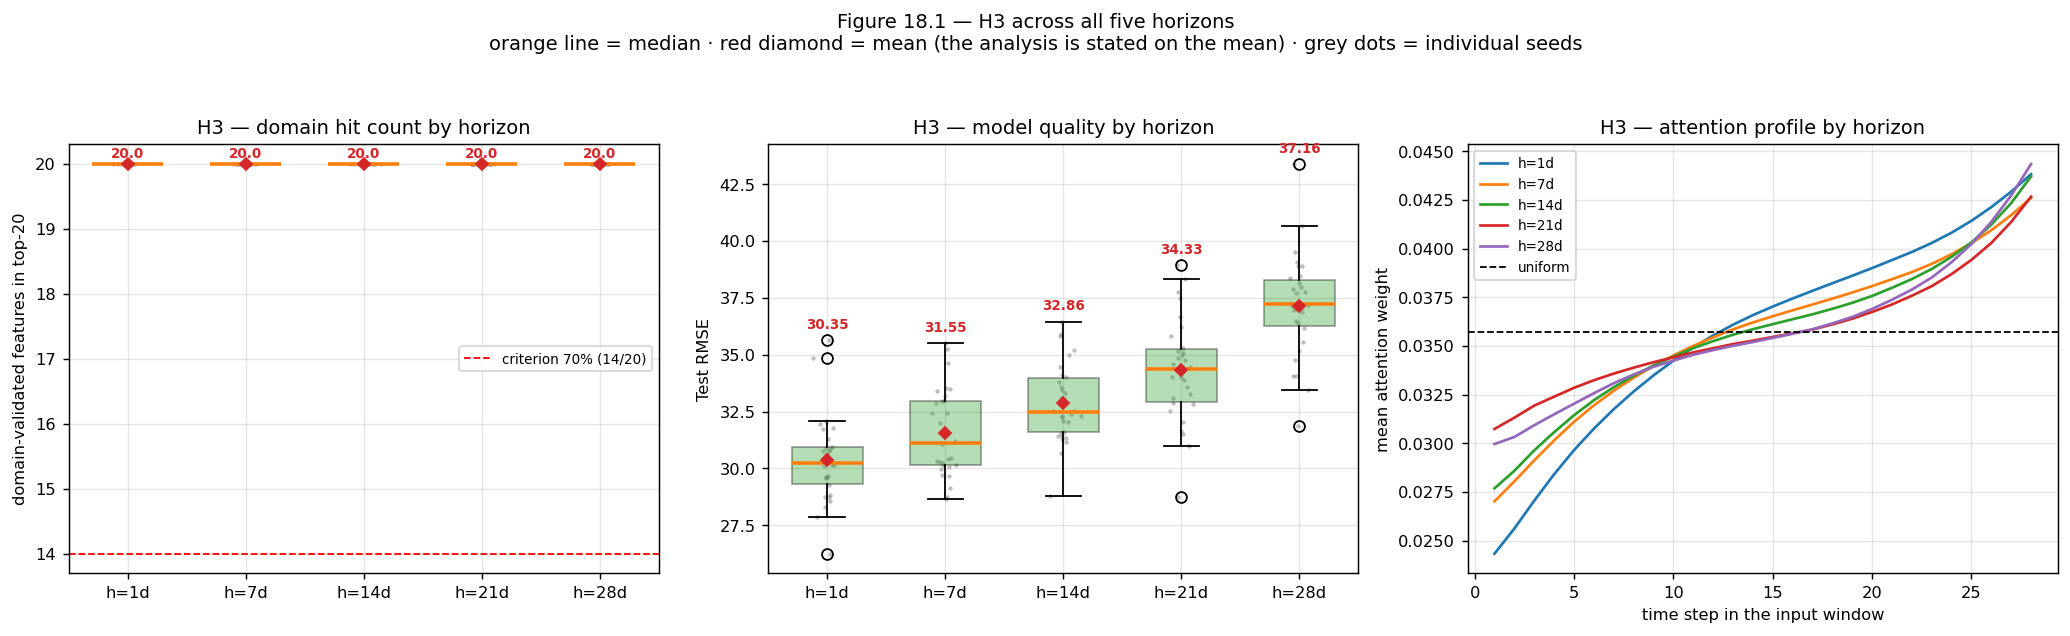

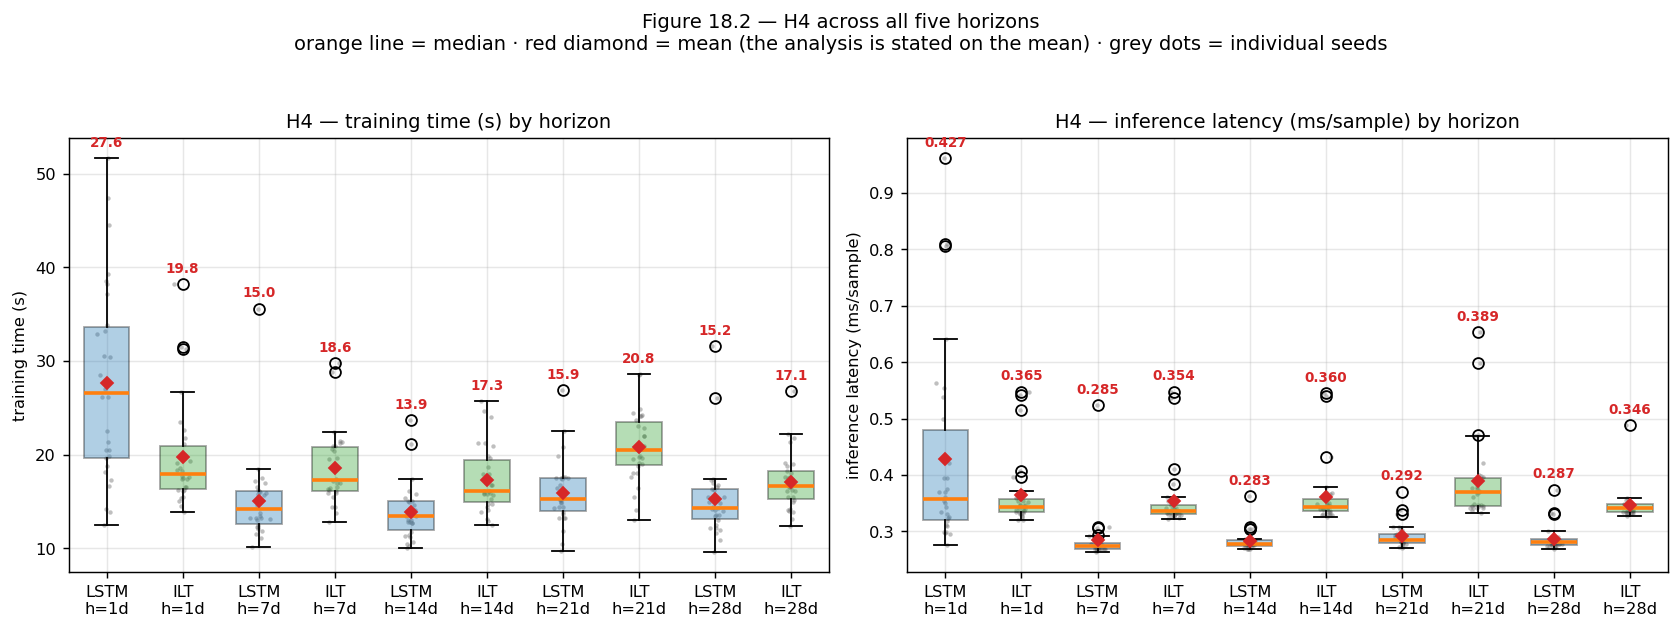

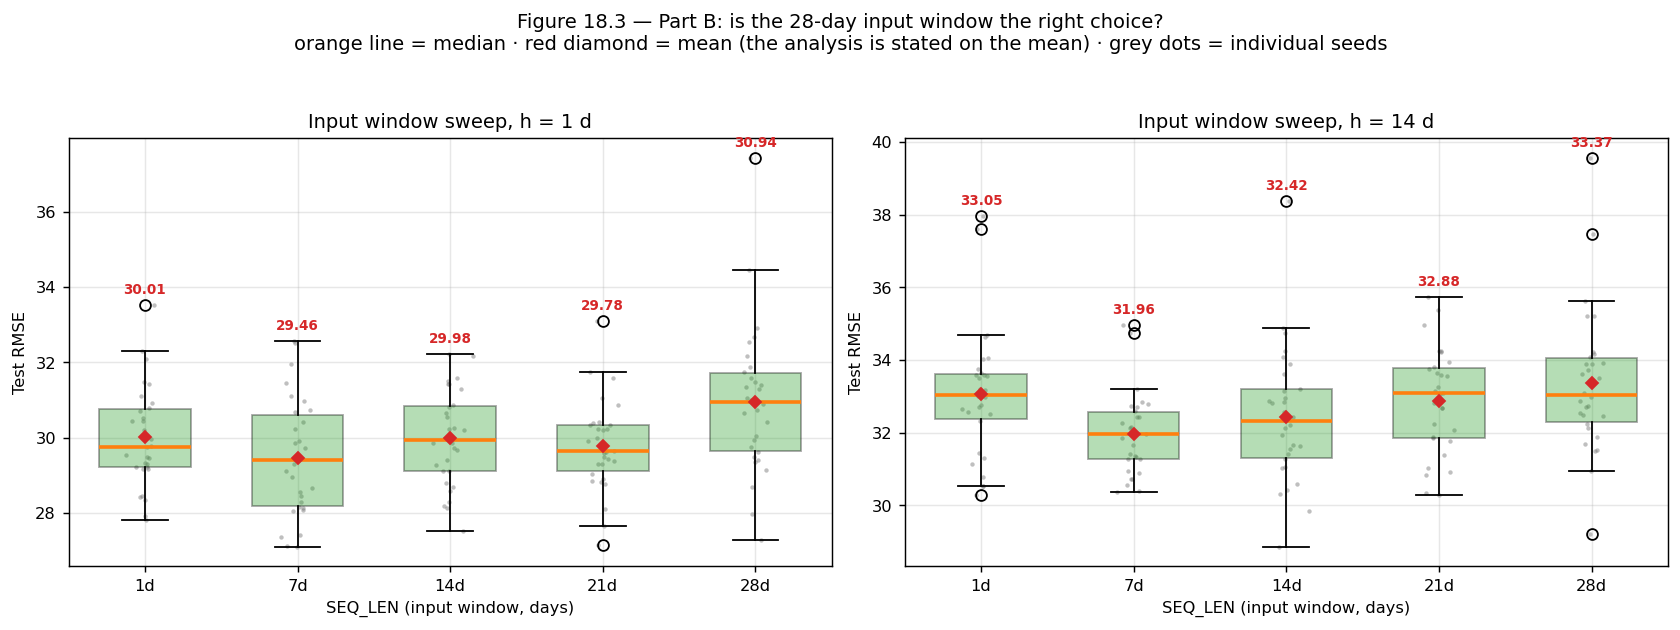

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
boxplot_mean_median(axes[0], [H3[H3.horizon == h].hits20.values for h in HORIZONS],
                    [f'h={h}d' for h in HORIZONS], 'domain-validated features in top-20',
                    'H3 — domain hit count by horizon', fmt='{:.1f}')
axes[0].axhline(14, color='r', ls='--', lw=1, label='criterion 70% (14/20)'); axes[0].legend(fontsize=7.5)
boxplot_mean_median(axes[1], [H3[H3.horizon == h].rmse.values for h in HORIZONS],
                    [f'h={h}d' for h in HORIZONS], 'Test RMSE', 'H3 — model quality by horizon')
for h in HORIZONS:
    axes[2].plot(range(1, h3_profiles[h].shape[1] + 1), h3_profiles[h].mean(axis=0), label=f'h={h}d')
axes[2].axhline(1 / 28, color='k', ls='--', lw=1, label='uniform')
axes[2].set_xlabel('time step in the input window'); axes[2].set_ylabel('mean attention weight')
axes[2].set_title('H3 — attention profile by horizon'); axes[2].legend(fontsize=7.5); axes[2].grid(alpha=0.3)
fig.suptitle('Figure 18.1 — H3 across all five horizons\n' + LEGEND_NOTE, y=1.05)
fig.tight_layout(); fig.savefig('plots/nb18_h3_all_horizons.png', bbox_inches='tight', dpi=150); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, col, lab, fmt in [(axes[0], 'train_s', 'training time (s)', '{:.1f}'),
                          (axes[1], 'latency_ms', 'inference latency (ms/sample)', '{:.3f}')]:
    data, labels, colors = [], [], []
    for h in HORIZONS:
        for mdl, c in [('Standalone LSTM', '#1f77b4'), ('ILT (proposed)', '#2ca02c')]:
            data.append(EFF[(EFF.horizon == h) & (EFF.model == mdl)][col].values)
            labels.append(f'{"LSTM" if "Stand" in mdl else "ILT"}\nh={h}d'); colors.append(c)
    boxplot_mean_median(ax, data, labels, lab, f'H4 — {lab} by horizon', fmt=fmt, colors=colors)
fig.suptitle('Figure 18.2 — H4 across all five horizons\n' + LEGEND_NOTE, y=1.04)
fig.tight_layout(); fig.savefig('plots/nb18_h4_all_horizons.png', bbox_inches='tight', dpi=150); plt.show()

fig, axes = plt.subplots(1, len(SWEEP_HORIZONS), figsize=(6.5 * len(SWEEP_HORIZONS), 4.6), squeeze=False)
for ax, h in zip(axes[0], SWEEP_HORIZONS):
    boxplot_mean_median(ax, [WIN[(WIN.horizon == h) & (WIN.seq_len == sl)].rmse.values for sl in WINDOW_SWEEP],
                        [f'{sl}d' for sl in WINDOW_SWEEP], 'Test RMSE',
                        f'Input window sweep, h = {h} d')
    ax.set_xlabel('SEQ_LEN (input window, days)')
fig.suptitle('Figure 18.3 — Part B: is the 28-day input window the right choice?\n' + LEGEND_NOTE, y=1.04)
fig.tight_layout(); fig.savefig('plots/nb18_window_sweep.png', bbox_inches='tight', dpi=150); plt.show()

## Conclusion to carry into the workbook

Copy the three printed test tables into the **H3**, **H4** and **Methodology** sheets. The sentence
the examiner is looking for has the form:

> *"H3 / H4 was evaluated at all five horizons (1, 7, 14, 21, 28 days). The criterion is met at
> [which horizons], with Holm-corrected p = [...]; the conclusion is stated only after all five."*

If any horizon fails, say so in that sentence — a hypothesis that holds at four of five horizons is
a more credible finding than one asserted everywhere, and the examiner has already signalled that
they read the per-horizon detail.